#### 1. Импорты модулей и перевод вычислений на GPU

In [ ]:
# pytorch 
import torch 

# данные 
from torchvision import datasets as ds 
from torch.utils.data import DataLoader

# трансформации 
from torchvision import transforms as tfs 

# построение нейронной сети 
import torch.nn as nn 

# оптимизаторы 
import torch.optim as optim 

# обучение модели 
from tqdm import tqdm

# проверка на тестовой картинке из интернета 
import requests
from PIL import Image
from io import BytesIO
import torch

In [180]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(device)

cuda


<hr>

#### 2. Загрузка данных 

In [181]:
transform = tfs.Compose([
    tfs.ToTensor(), 
])

In [182]:
train_dataset = ds.CIFAR10(
    root="./data",
    train=True,
    transform=transform,
    download=True
)

test_dataset = ds.CIFAR10(
    root="./data",
    train=False,
    transform=transform,
    download=True
)

In [183]:
train_data = DataLoader(train_dataset, batch_size=32, shuffle=True, drop_last=True)
test_data = DataLoader(test_dataset, batch_size=32, shuffle=False)

<hr>

#### 3. Построение модели нейронной сети. 

За основу взята архитектура ResNet18 с Basic блоками. 

Layer1 (выход [64, H, W]):

In [184]:
# выход [64, H, W]
class BasicBlock1(nn.Module): 
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Sequential(
            nn.Conv2d(in_channels=64, out_channels=64, kernel_size=(3, 3), stride=1, padding=1, bias=False),
            nn.BatchNorm2d(64), 
            nn.ReLU(inplace=True),
            nn.Conv2d(in_channels=64, out_channels=64, kernel_size=(3, 3), stride=1, padding=1, bias=False),
            nn.BatchNorm2d(64)
        )
        self.shortcut = nn.Identity()
        self.relu = nn.ReLU() 
        
    def forward(self, x):
        out = self.conv1(x) + self.shortcut(x)
        out = self.relu(out) 
        
        return out 
    
# выход [64, H, W]
class BasicBlock2(nn.Module): 
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Sequential(
            nn.Conv2d(in_channels=64, out_channels=64, kernel_size=(3, 3), stride=1, padding=1, bias=False),
            nn.BatchNorm2d(64), 
            nn.ReLU(inplace=True),
            nn.Conv2d(in_channels=64, out_channels=64, kernel_size=(3, 3), stride=1, padding=1, bias=False),
            nn.BatchNorm2d(64)
        ) 
        self.shortcut = nn.Identity()
        self.relu = nn.ReLU() 
        
    def forward(self, x):
        out = self.conv1(x) + self.shortcut(x)
        out = self.relu(out)
        
        return out 

Layer2 (выход [128, H/2, W/2]):

In [185]:
# выход [128, H/2, W/2]
class BasicBlock3(nn.Module): 
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Sequential(
            nn.Conv2d(in_channels=64, out_channels=128, kernel_size=(3, 3), stride=2, padding=1, bias=False),
            nn.BatchNorm2d(128), 
            nn.ReLU(inplace=True),
            nn.Conv2d(in_channels=128, out_channels=128, kernel_size=(3, 3), stride=1, padding=1, bias=False),
            nn.BatchNorm2d(128)
        )
        self.shortcut = nn.Sequential(
            nn.Conv2d(in_channels=64, out_channels=128, kernel_size=(1, 1), stride=2, padding=0, bias=False),
            nn.BatchNorm2d(128)
        ) 
        self.relu = nn.ReLU() 
        
    def forward(self, x):
         
        out = self.conv1(x) + self.shortcut(x)
        out = self.relu(out) 
        
        return out 
    
# выход [128, H/2, W/2]
class BasicBlock4(nn.Module): 
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Sequential(
            nn.Conv2d(in_channels=128, out_channels=128, kernel_size=(3, 3), stride=1, padding=1, bias=False),
            nn.BatchNorm2d(128), 
            nn.ReLU(inplace=True),
            nn.Conv2d(in_channels=128, out_channels=128, kernel_size=(3, 3), stride=1, padding=1, bias=False),
            nn.BatchNorm2d(128)
        )
        self.shortcut = nn.Identity()
        self.relu = nn.ReLU() 
        
    def forward(self, x):
         
        out = self.conv1(x) + self.shortcut(x)
        out = self.relu(out) 
        
        return out 

Layer3 (выход [256, H/4, W/4])

In [186]:
# выход [256, H/4, W/4]
class BasicBlock5(nn.Module): 
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Sequential(
            nn.Conv2d(in_channels=128, out_channels=256, kernel_size=(3, 3), stride=2, padding=1, bias=False),
            nn.BatchNorm2d(256), 
            nn.ReLU(inplace=True),
            nn.Conv2d(in_channels=256, out_channels=256, kernel_size=(3, 3), stride=1, padding=1, bias=False),
            nn.BatchNorm2d(256)
        )
        self.shortcut = nn.Sequential(
            nn.Conv2d(in_channels=128, out_channels=256, kernel_size=(1, 1), stride=2, padding=0, bias=False),
            nn.BatchNorm2d(256)
        ) 
        self.relu = nn.ReLU(inplace=True) 
        
    def forward(self, x):
         
        out = self.conv1(x) + self.shortcut(x)
        out = self.relu(out) 
        
        return out 
    
# выход [256, H/4, W/4]
class BasicBlock6(nn.Module): 
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Sequential(
            nn.Conv2d(in_channels=256, out_channels=256, kernel_size=(3, 3), stride=1, padding=1, bias=False),
            nn.BatchNorm2d(256), 
            nn.ReLU(inplace=True),
            nn.Conv2d(in_channels=256, out_channels=256, kernel_size=(3, 3), stride=1, padding=1, bias=False),
            nn.BatchNorm2d(256)
        )
        self.shortcut = nn.Identity()
        self.relu = nn.ReLU() 
        
    def forward(self, x):
         
        out = self.conv1(x) + self.shortcut(x)
        out = self.relu(out) 
        
        return out 

Layer4 (выход [512, H/8, W/8])

In [187]:
# выход [512, H/8, W/8]
class BasicBlock7(nn.Module): 
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Sequential(
            nn.Conv2d(in_channels=256, out_channels=512, kernel_size=(3, 3), stride=2, padding=1, bias=False),
            nn.BatchNorm2d(512), 
            nn.ReLU(inplace=True),
            nn.Conv2d(in_channels=512, out_channels=512, kernel_size=(3, 3), stride=1, padding=1, bias=False),
            nn.BatchNorm2d(512)
        )
        self.shortcut = nn.Sequential(
            nn.Conv2d(in_channels=256, out_channels=512, kernel_size=(1, 1), stride=2, padding=0, bias=False),
            nn.BatchNorm2d(512)
        ) 
        self.relu = nn.ReLU(inplace=True) 
        
    def forward(self, x):
         
        out = self.conv1(x) + self.shortcut(x)
        out = self.relu(out) 
        
        return out 
    
# выход [512, H/8, W/8]
class BasicBlock8(nn.Module): 
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Sequential(
            nn.Conv2d(in_channels=512, out_channels=512, kernel_size=(3, 3), stride=1, padding=1, bias=False),
            nn.BatchNorm2d(512), 
            nn.ReLU(inplace=True),
            nn.Conv2d(in_channels=512, out_channels=512, kernel_size=(3, 3), stride=1, padding=1, bias=False),
            nn.BatchNorm2d(512)
        )
        self.shortcut = nn.Identity()
        self.relu = nn.ReLU() 
        
    def forward(self, x):
         
        out = self.conv1(x) + self.shortcut(x)
        out = self.relu(out) 
        
        return out 

In [188]:
class CIFAR_Classifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=64, kernel_size=(3, 3), stride=1, padding=1, bias=False),
            nn.BatchNorm2d(64),
         )
        self.layer1 = nn.Sequential(
            BasicBlock1(), 
            BasicBlock2(),
         )
        self.layer2 = nn.Sequential(
            BasicBlock3(),
            BasicBlock4(),
        )
        
        self.layer3 = nn.Sequential(
            BasicBlock5(),
            BasicBlock6(),
        )

        self.layer4 = nn.Sequential(
            BasicBlock7(),
            BasicBlock8(),
        )
        
        self.linear = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(512, 10, bias=True),
        )
            
    def forward(self, x):
        out = self.conv1(x)
        
        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        out = self.layer4(out)
        
        out = self.linear(out)
        
        return out   

In [189]:
model = CIFAR_Classifier().to(device)

In [190]:
epoch = 5 
loss_func = nn.CrossEntropyLoss()
optimizer = optim.Adam(params=model.parameters(), lr=0.001, weight_decay=0.0001)


for _ in range(epoch):
    
    model.train()
    
    for X_train, y_train in tqdm(train_data): 
        
        X_train = X_train.to(device)
        y_train = y_train.to(device)
        
        predictions = model(X_train)
        
        loss = loss_func(predictions, y_train)
        
        optimizer.zero_grad()
        loss.backward() 
        optimizer.step()

100%|██████████| 1562/1562 [00:39<00:00, 39.37it/s]


In [191]:
model.eval() 

CIFAR_Classifier(
  (conv1): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  )
  (layer1): Sequential(
    (0): BasicBlock1(
      (conv1): Sequential(
        (0): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      )
      (shortcut): Identity()
      (relu): ReLU()
    )
    (1): BasicBlock2(
      (conv1): Sequential(
        (0): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bia

In [223]:
torch.save(
    model.state_dict(),
    "cifar_resnet.pth"
)

<hr>

#### 4. Оценка качества обученой модели

In [192]:
predictions_mask = torch.empty(0, dtype=torch.long).to(device)

for X_test, y_test in test_data: 
    
    X_test = X_test.to(device)
    y_test = y_test.to(device)
    
    predictions = model(X_test)
    
    prediction_mask = (predictions.argmax(dim=1) == y_test).long()
    
    predictions_mask = torch.cat(
        (predictions_mask, prediction_mask),
        dim=0
    )

In [193]:
Q = predictions_mask.sum().item() / 10000

print(f'Accuracy на test выборке: {Q}')

Accuracy на test выборке: 0.8157


In [210]:
predictions_mask = torch.empty(0, dtype=torch.long).to(device)

for X_train, y_train in train_data: 
    
    X_train = X_train.to(device)
    y_train = y_train.to(device)
    
    with torch.no_grad():
        predictions = model(X_train)
        
        prediction_mask = (predictions.argmax(dim=1) == y_train).long()
        
        predictions_mask = torch.cat(
            (predictions_mask, prediction_mask),
            dim=0
        )

In [211]:
Q = predictions_mask.sum().item() / 50000

print(f'Accuracy на test выборке: {Q}')

Accuracy на test выборке: 0.88176


<hr>

#### 4. Проверка работы на картинке из интернета. 

(np.float64(-0.5), np.float64(416.5), np.float64(625.5), np.float64(-0.5))

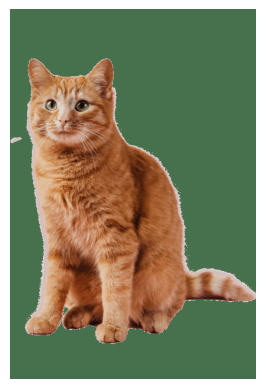

In [212]:
url = "https://vetson.ru/upload/iblock/1bd/c73x437pcxc6afyjij70rduo6rw7g0rh.png"

response = requests.get(url)
image = Image.open(BytesIO(response.content)).convert("RGB")

plt.imshow(image)
plt.axis("off")

In [213]:
transform_test = tfs.Compose([
    tfs.Resize((32, 32)),
    tfs.ToTensor()
])

In [214]:
image_tensor = transform_test(image)
image_tensor = image_tensor.unsqueeze(0)

In [215]:
print(image_tensor.shape)

torch.Size([1, 3, 32, 32])


In [216]:
image_tensor = image_tensor.to(device)

In [221]:
classes = [
    "airplane",
    "automobile",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck"
]

with torch.no_grad():
    prediction = model(image_tensor)
    
predicted_class = prediction.argmax(dim=1).item()


print(f'Классификация модели: {classes[predicted_class]}')

Классификация модели: cat


In [222]:
probabilities = torch.softmax(prediction, dim=1)

for class_name, probability in zip(classes, probabilities[0]):
    print(f"{class_name}: {probability.item():.2%}")

airplane: 0.00%
automobile: 0.00%
bird: 0.01%
cat: 51.11%
deer: 0.02%
dog: 48.85%
frog: 0.01%
horse: 0.00%
ship: 0.00%
truck: 0.00%
